In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_excel(
    "sentiment_analysis.xlsx",
    sheet_name="sentiment_analysis.csv"
)

In [5]:
df.head(5)

,Review_ID,Word_Count,Exclamation_Marks,Question_Marks,Uppercase_Words,Avg_Word_Length,Unique_Words_Ratio,Negative_Words_Count,Positive_Words_Count,Sentiment_Score,...,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Q1,Q3,IQR
0,REV0001,112,7,2,6,6.76,0.65,3,3,-0.26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,7,5
1,REV0002,445,0,2,19,6.31,0.42,2,7,-0.33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lower limit,upper limit
2,REV0003,358,8,4,4,5.67,0.78,12,2,0.77,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5.5,14.5
3,REV0004,280,5,4,0,5.31,0.99,0,8,-0.23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,REV0005,116,6,0,16,4.39,0.82,2,1,-0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,11,8


In [6]:
df.tail()

,Review_ID,Word_Count,Exclamation_Marks,Question_Marks,Uppercase_Words,Avg_Word_Length,Unique_Words_Ratio,Negative_Words_Count,Positive_Words_Count,Sentiment_Score,...,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Q1,Q3,IQR
495,REV0496,164,4,0,13,6.07,0.42,6,2,0.04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
496,REV0497,499,5,3,3,5.93,0.71,8,0,0.04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
497,REV0498,395,3,0,0,4.20,1.00,7,10,0.18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
498,REV0499,483,9,1,0,3.69,0.41,7,15,0.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
499,REV0500,282,1,0,18,5.55,0.87,12,17,0.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.shape

(500, 30)

In [5]:
columns = [
    "Review_ID",
    "Word_Count",
    "Exclamation_Marks",
    "Question_Marks",
    "Uppercase_Words",
    "Avg_Word_Length",
    "Unique_Words_Ratio",
    "Negative_Words_Count",
    "Positive_Words_Count",
    "Sentiment_Score",
    "Sentiment"
]

df = df[columns]

In [6]:
df.columns

Index(['Review_ID', 'Word_Count', 'Exclamation_Marks', 'Question_Marks',
       'Uppercase_Words', 'Avg_Word_Length', 'Unique_Words_Ratio',
       'Negative_Words_Count', 'Positive_Words_Count', 'Sentiment_Score',
       'Sentiment'],
      dtype='str')

In [ ]:
df.info()

<bound method DataFrame.info of     Review_ID  Word_Count  Exclamation_Marks  Question_Marks  Uppercase_Words  \
0     REV0001         112                  7               2                6   
1     REV0002         445                  0               2               19   
2     REV0003         358                  8               4                4   
3     REV0004         280                  5               4                0   
4     REV0005         116                  6               0               16   
..        ...         ...                ...             ...              ...   
495   REV0496         164                  4               0               13   
496   REV0497         499                  5               3                3   
497   REV0498         395                  3               0                0   
498   REV0499         483                  9               1                0   
499   REV0500         282                  1               0               18

In [9]:
df.isnull().sum()

Review_ID               0
Word_Count              0
Exclamation_Marks       0
Question_Marks          0
Uppercase_Words         0
Avg_Word_Length         0
Unique_Words_Ratio      0
Negative_Words_Count    0
Positive_Words_Count    0
Sentiment_Score         0
Sentiment               0
dtype: int64

In [10]:
df.isnull().sum().sum()

np.int64(0)

In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.describe()

,Word_Count,Exclamation_Marks,Question_Marks,Uppercase_Words,Avg_Word_Length,Unique_Words_Ratio,Negative_Words_Count,Positive_Words_Count,Sentiment_Score,Positive Review,...,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Q1
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,11.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.000000
mean,259.892000,4.542000,1.964000,9.500000,4.966220,0.647660,6.806000,9.640000,0.051700,44.241567,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000
std,139.434861,2.982285,1.425049,5.755019,1.119644,0.206263,4.315276,5.913064,0.559359,90.353122,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.707107
min,11.000000,0.000000,0.000000,0.000000,3.000000,0.300000,0.000000,0.000000,-0.990000,0.051700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000
25%,142.250000,2.000000,1.000000,4.000000,3.967500,0.460000,3.000000,4.000000,-0.380000,1.305830,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.250000
50%,261.000000,4.000000,2.000000,10.000000,5.005000,0.640000,7.000000,9.000000,0.060000,4.966220,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000
75%,381.250000,7.000000,3.000000,14.000000,5.942500,0.830000,11.000000,15.000000,0.542500,9.570000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.750000
max,499.000000,9.000000,4.000000,19.000000,6.980000,1.000000,14.000000,19.000000,0.980000,259.892000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000


In [6]:
df["Sentiment_Score"].mean()

np.float64(0.0517)

In [8]:
df["Word_Count"].median()

np.float64(261.0)

In [10]:
df["Sentiment"].mode()

0    Positive
Name: Sentiment, dtype: str

In [11]:
df["Sentiment"].value_counts()

Sentiment
Positive    188
Neutral     168
Negative    144
Name: count, dtype: int64

In [12]:
df["Sentiment"].value_counts(normalize=True)*100

Sentiment
Positive    37.6
Neutral     33.6
Negative    28.8
Name: proportion, dtype: float64

In [13]:
df["Word_Count"].max()-df["Word_Count"].min()

np.int64(488)

In [3]:
df["Word_Count"].quantile(0.25)

np.float64(142.25)

In [4]:
df["Word_Count"].quantile(0.75)

np.float64(381.25)

In [7]:
Q1 = df["Word_Count"].quantile(0.25)
Q3 = df["Word_Count"].quantile(0.75)
IQR = Q3 - Q1
print(IQR)
lower_limit = Q1 - 1.5 *IQR 
Upper_limit = Q3 + 1.5 *IQR 
outliers= df[(df["Word_Count"]<lower_limit)|
            (df["Word_Count"]>Upper_limit)]
print(outliers)

239.0
Empty DataFrame
Columns: [Review_ID, Word_Count, Exclamation_Marks, Question_Marks, Uppercase_Words, Avg_Word_Length, Unique_Words_Ratio, Negative_Words_Count, Positive_Words_Count, Sentiment_Score, Outlier, Outlier2, Sentiment, Positive Review, Negative, Neutral, Unnamed: 16, Unnamed: 17, Unnamed: 18, Unnamed: 19, Unnamed: 20, Unnamed: 21, Unnamed: 22, Unnamed: 23, Unnamed: 24, Unnamed: 25, Unnamed: 26, Q1, Q3, IQR]
Index: []

[0 rows x 30 columns]


In [9]:
Positive = df[df["Sentiment"]=="Positive"]
print(Positive)

    Review_ID  Word_Count  Exclamation_Marks  Question_Marks  Uppercase_Words  \
2     REV0003         358                  8               4                4   
6     REV0007         198                  6               4               12   
10    REV0011         476                  8               0               17   
12    REV0013         340                  9               2               15   
15    REV0016         382                  3               1               14   
..        ...         ...                ...             ...              ...   
486   REV0487         183                  3               1               17   
487   REV0488         289                  5               2               17   
489   REV0490         297                  7               3                7   
492   REV0493         160                  2               4               16   
498   REV0499         483                  9               1                0   

     Avg_Word_Length  Uniqu

In [10]:
Negative = df[df["Sentiment"]== "Negative"]

In [11]:
df.sort_values("Sentiment_Score",ascending=False)

,Review_ID,Word_Count,Exclamation_Marks,Question_Marks,Uppercase_Words,Avg_Word_Length,Unique_Words_Ratio,Negative_Words_Count,Positive_Words_Count,Sentiment_Score,...,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Q1,Q3,IQR
10,REV0011,476,8,0,17,6.01,0.42,7,7,0.98,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
172,REV0173,14,2,0,11,3.00,0.39,7,4,0.98,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
440,REV0441,462,5,1,17,4.50,0.57,5,3,0.98,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
492,REV0493,160,2,4,16,4.49,0.46,10,7,0.98,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
249,REV0250,161,0,2,7,3.07,0.80,14,15,0.97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54,REV0055,140,7,1,2,5.08,0.69,3,13,-0.98,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42,REV0043,197,6,3,16,6.39,0.49,3,16,-0.98,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
279,REV0280,233,9,4,12,4.42,0.74,1,14,-0.99,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
298,REV0299,264,4,1,8,3.17,0.79,2,16,-0.99,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df.sort_values("Sentiment_Score",ascending=True)

,Review_ID,Word_Count,Exclamation_Marks,Question_Marks,Uppercase_Words,Avg_Word_Length,Unique_Words_Ratio,Negative_Words_Count,Positive_Words_Count,Sentiment_Score,...,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Q1,Q3,IQR
428,REV0429,447,5,2,14,6.25,0.56,5,15,-0.99,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
298,REV0299,264,4,1,8,3.17,0.79,2,16,-0.99,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
279,REV0280,233,9,4,12,4.42,0.74,1,14,-0.99,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42,REV0043,197,6,3,16,6.39,0.49,3,16,-0.98,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
402,REV0403,77,5,0,4,3.72,0.79,7,1,-0.98,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432,REV0433,235,9,0,16,3.78,0.66,9,1,0.97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
172,REV0173,14,2,0,11,3.00,0.39,7,4,0.98,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
492,REV0493,160,2,4,16,4.49,0.46,10,7,0.98,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,REV0011,476,8,0,17,6.01,0.42,7,7,0.98,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df.groupby("Sentiment")["Sentiment_Score"].mean()

Sentiment
Negative   -0.651806
Neutral    -0.008750
Positive    0.644574
Name: Sentiment_Score, dtype: float64

In [14]:
df.groupby("Sentiment")["Word_Count"].mean()

Sentiment
Negative    263.743056
Neutral     252.666667
Positive    263.398936
Name: Word_Count, dtype: float64

In [16]:
df.groupby("Sentiment").agg({"Word_Count":"mean","Sentiment_Score":"mean"})

,Word_Count,Sentiment_Score
Sentiment,,
Negative,263.743056,-0.651806
Neutral,252.666667,-0.008750
Positive,263.398936,0.644574


In [17]:
pd.pivot_table(
    df,
    values="Sentiment_Score",
    index="Sentiment",
    aggfunc="mean"
)

,Sentiment_Score
Sentiment,
Negative,-0.651806
Neutral,-0.008750
Positive,0.644574


In [3]:
np.mean(df["Sentiment_Score"])

np.float64(0.0517)

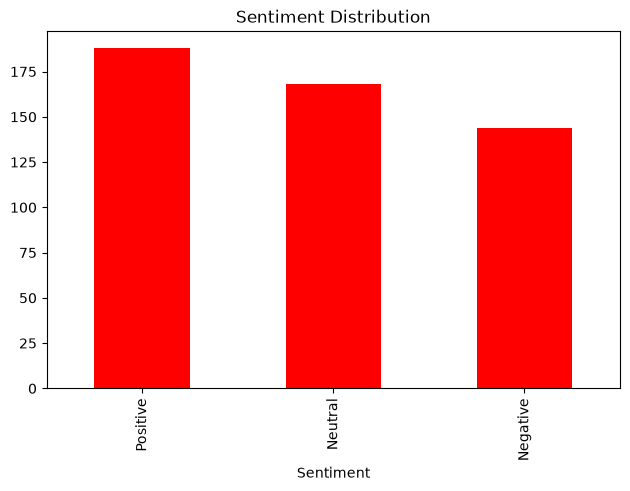

In [4]:
df["Sentiment"].value_counts().plot(kind="bar",color=["red"])
plt.tight_layout()
plt.title("Sentiment Distribution")
plt.show()

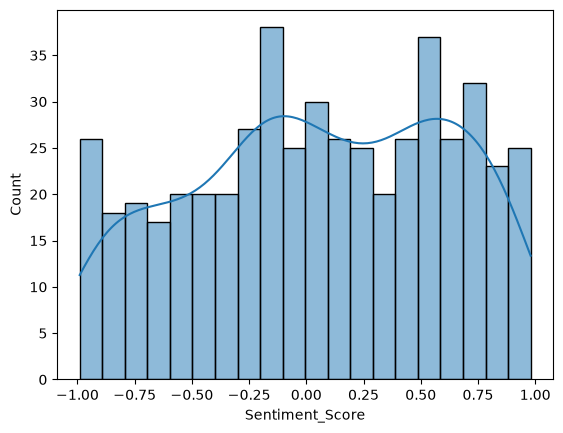

In [5]:
sns.histplot(df["Sentiment_Score"],bins=20,kde=True)
plt.show()

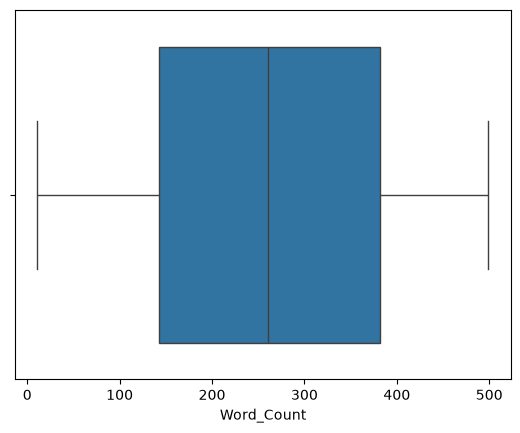

In [6]:
sns.boxplot(x=df["Word_Count"])
plt.show()

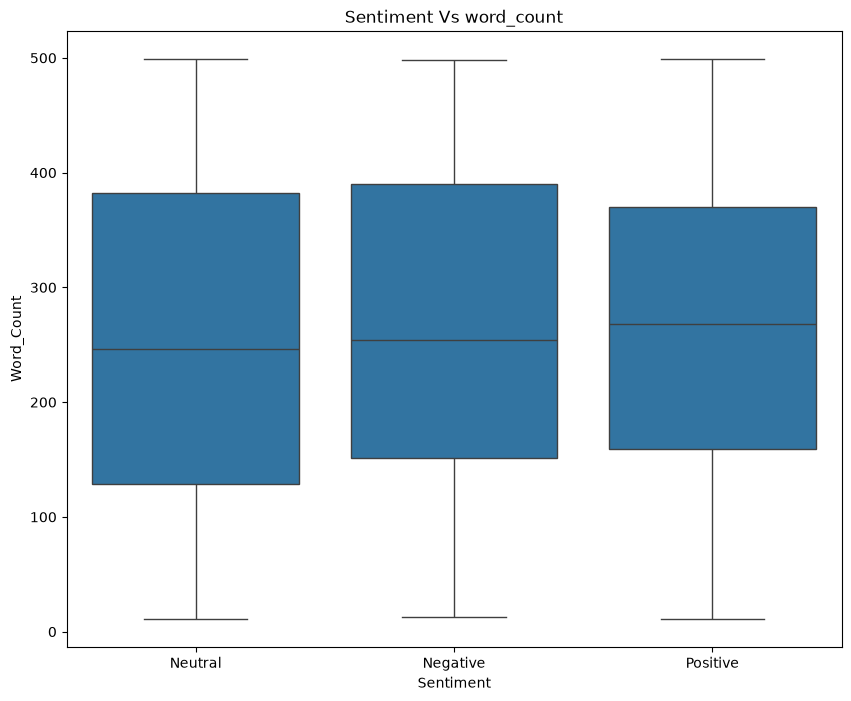

In [13]:
plt.figure(figsize=(10,8))
sns.boxplot(x="Sentiment",y="Word_Count",data=df)
plt.title("Sentiment Vs word_count")
plt.show()

c:\Users\hp\OneDrive\Desktop\data analysis\.venv\Lib\site-packages\seaborn\utils.py:105: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scout = method(scout_x, scout_y, **kws)
c:\Users\hp\OneDrive\Desktop\data analysis\.venv\Lib\site-packages\seaborn\relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


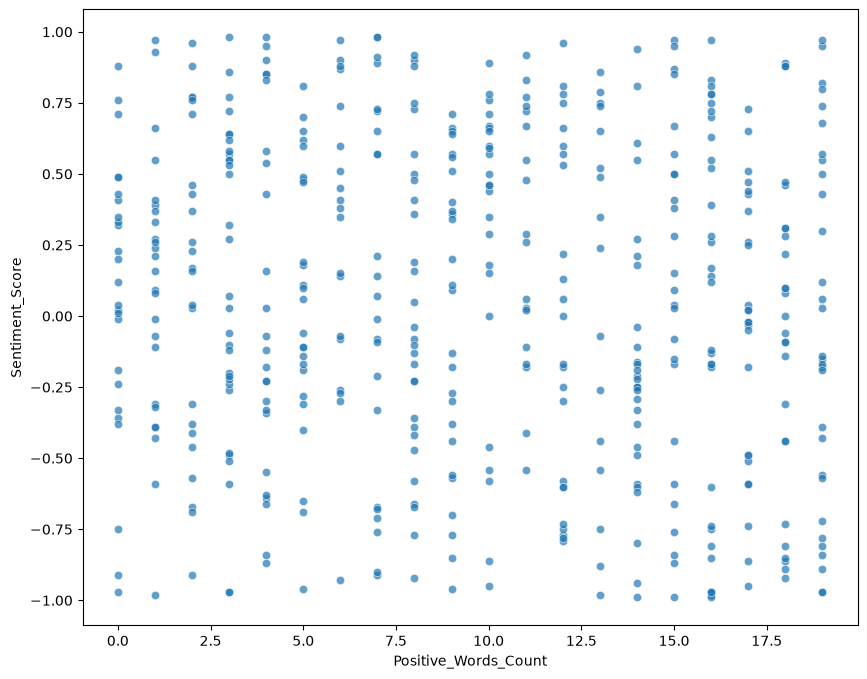

In [16]:
plt.figure(figsize=(10,8))

sns.scatterplot(x="Positive_Words_Count",
                y="Sentiment_Score",
                cmap="virdis",
                alpha=0.7,
                marker="o",
                data=df)
plt.show()

In [17]:
numeric_df=df.select_dtypes(include="number")
numeric_df.corr()

,Word_Count,Exclamation_Marks,Question_Marks,Uppercase_Words,Avg_Word_Length,Unique_Words_Ratio,Negative_Words_Count,Positive_Words_Count,Sentiment_Score,Positive Review,...,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Q1
Word_Count,1.000000,-0.063039,-0.007917,0.033817,-0.030470,-0.048609,-0.004088,0.016491,0.031621,0.189530,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
Exclamation_Marks,-0.063039,1.000000,-0.032651,0.097205,0.008225,0.054419,-0.049585,0.020974,-0.018850,0.254043,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0
Question_Marks,-0.007917,-0.032651,1.000000,-0.022236,0.051411,0.018666,0.029821,0.046262,0.040101,0.349018,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0
Uppercase_Words,0.033817,0.097205,-0.022236,1.000000,-0.003429,-0.073125,0.006335,0.036924,0.070934,-0.784829,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
Avg_Word_Length,-0.030470,0.008225,0.051411,-0.003429,1.000000,0.022690,-0.084840,-0.004970,0.003744,0.264260,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0
Unique_Words_Ratio,-0.048609,0.054419,0.018666,-0.073125,0.022690,1.000000,0.062238,0.017366,-0.035033,-0.041071,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
Negative_Words_Count,-0.004088,-0.049585,0.029821,0.006335,-0.084840,0.062238,1.000000,-0.035650,0.020361,0.539380,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0
Positive_Words_Count,0.016491,0.020974,0.046262,0.036924,-0.004970,0.017366,-0.035650,1.000000,-0.093970,-0.497352,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0
Sentiment_Score,0.031621,-0.018850,0.040101,0.070934,0.003744,-0.035033,0.020361,-0.093970,1.000000,0.161278,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
Positive Review,0.189530,0.254043,0.349018,-0.784829,0.264260,-0.041071,0.539380,-0.497352,0.161278,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0


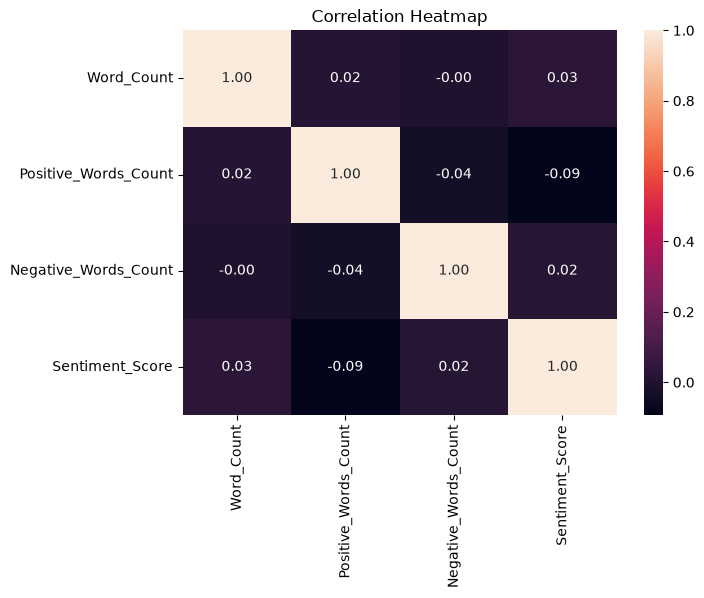

In [19]:
important_cols = [
    "Word_Count",
    "Positive_Words_Count",
    "Negative_Words_Count",
    "Sentiment_Score"
]

corr = df[important_cols].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

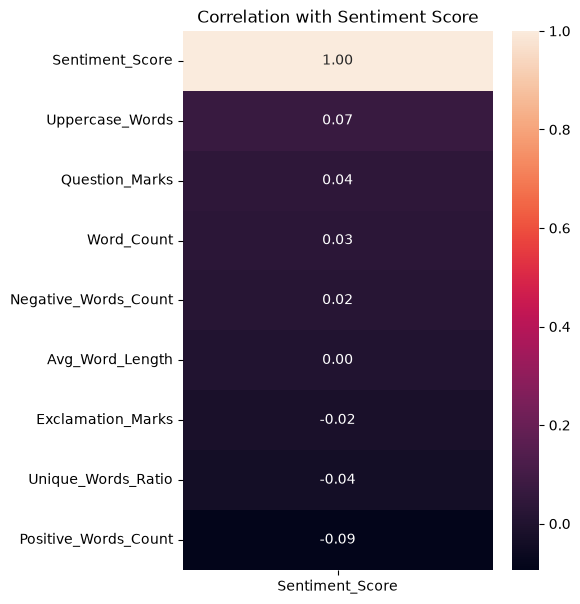

In [3]:
corr = df[
    [
        "Word_Count",
        "Exclamation_Marks",
        "Question_Marks",
        "Uppercase_Words",
        "Avg_Word_Length",
        "Unique_Words_Ratio",
        "Negative_Words_Count",
        "Positive_Words_Count",
        "Sentiment_Score"
    ]
].corr()

sentiment_corr = corr[
    ["Sentiment_Score"]
].sort_values(
    by="Sentiment_Score",
    ascending=False
)

plt.figure(figsize=(5, 7))

sns.heatmap(
    sentiment_corr,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation with Sentiment Score")
plt.show()

In [4]:
from scipy.stats import ttest_ind

In [5]:
positive = df[df["Sentiment"]=="Positive"]["Word_Count"]
negative = df[df["Sentiment"]=="Negative"]["Word_Count"]
t_stat,p_value=ttest_ind(positive,negative)
print(p_value)

0.9820249378820777


In [6]:
from scipy.stats import f_oneway
positive = df[df["Sentiment"]=="Positive"]["Word_Count"]
neutral = df[df["Sentiment"]=="Neutral"]["Word_Count"]
negative = df[df["Sentiment"]=="Negative"]["Word_Count"]
f_stat,p_value=f_oneway(positive,neutral,negative)
print(p_value)

0.7126193524682414
